In [43]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
import math
import matplotlib.dates as mdates

In [2]:
# Connect to PostgreSQL and fetch data
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    port="5432"
)
cur = conn.cursor()

Count transactions

In [150]:
cur.execute("""
SELECT
    (SELECT COUNT(*) FROM transactions) AS total_tx,
    (SELECT SUM(user_tx_count) FROM checkpoints) AS user_tx,
    (SELECT SUM(system_tx_count) FROM checkpoints) AS system_tx,
    (SELECT COUNT(*) FROM checkpoints) AS total_checkpoints;
""")

total_tx, user_tx, system_tx, total_checkpoints = cur.fetchone()

print("Total transactions:", total_tx)
print("Total user tx:", user_tx)
print("Total system tx:", system_tx)
print("Total checkpoints:", total_checkpoints)


Total transactions: 769831
Total user tx: 759960
Total system tx: 12417
Total checkpoints: 12416


In [131]:
cur.execute("SELECT COUNT(*) FROM object_changes;")
total_object_changes = cur.fetchone()[0]
print("Total object changes:", total_object_changes)

Total object changes: 1735357


In [172]:
cur.execute("""SELECT digest FROM checkpoints WHERE sequence_number = '8830980';""")
hex_str = cur.fetchone()[0].hex()
digest_bytes = bytes.fromhex(hex_str)
base58_str = base58.b58encode(digest_bytes).decode()
print(base58_str)

ApR6EuacbTFPXtiPD71XbYGd1wTnTECYkT7JGn9K9Q9c


In [171]:
cur.execute("""SELECT sequence_number, timestamp
FROM checkpoints
ORDER BY sequence_number DESC
LIMIT 1;""")

sequence_number, timestamp = cur.fetchone()

print("Latest checkpoint sequence number:", sequence_number)
print("Latest checkpoint timestamp:", timestamp)


Latest checkpoint sequence number: 8830980
Latest checkpoint timestamp: 2023-07-28 08:30:14.334000+01:00


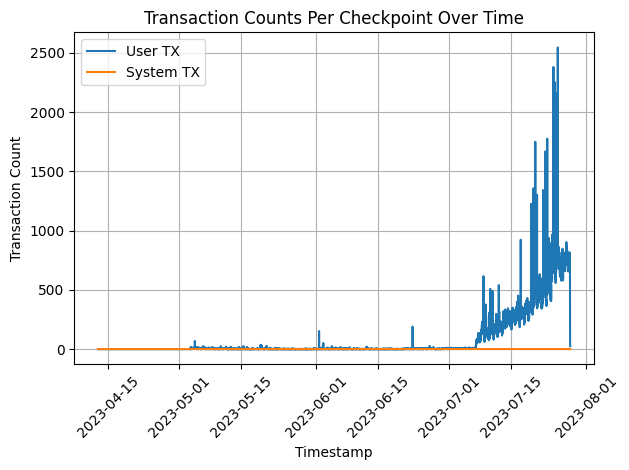

In [173]:
cur.execute("SELECT timestamp, user_tx_count, system_tx_count FROM checkpoints ORDER BY timestamp;")

rows = cur.fetchall()

df = pd.DataFrame(rows, columns=[
    "timestamp",
    "user_tx_count",
    "system_tx_count"
])

df["timestamp"] = pd.to_datetime(df["timestamp"])

plt.figure()
plt.plot(df["timestamp"], df["user_tx_count"], label="User TX")
plt.plot(df["timestamp"], df["system_tx_count"], label="System TX")

plt.xlabel("Timestamp")
plt.ylabel("Transaction Count")
plt.title("Transaction Counts Per Checkpoint Over Time")
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

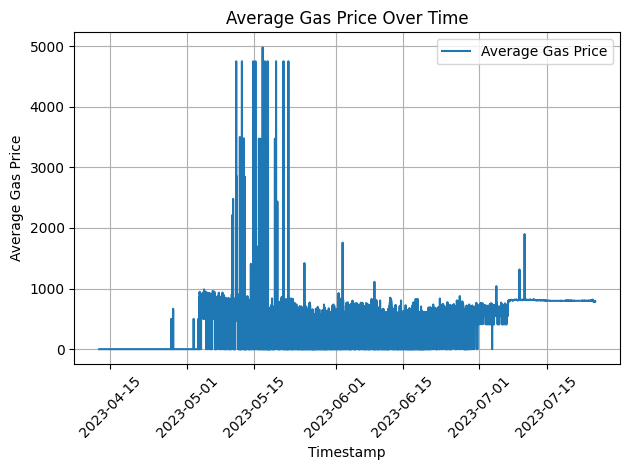

In [61]:
cur.execute("""
    SELECT 
        c.timestamp,
        AVG(t.gas_price) AS avg_gas_price
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
    GROUP BY c.timestamp
    ORDER BY c.timestamp;
""")

rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["timestamp", "avg_gas_price"])

df["timestamp"] = pd.to_datetime(df["timestamp"])

plt.figure()
plt.plot(df["timestamp"], df["avg_gas_price"], label="Average Gas Price")

plt.xlabel("Timestamp")
plt.ylabel("Average Gas Price")
plt.title("Average Gas Price Over Time")
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
def shorten_error(err):

    # Force bytes → str safely
    if isinstance(err, bytes):
        err = err.decode("utf-8", errors="replace")
    else:
        err = str(err)

    # Case 1: If Abort Code actually exists (clean numeric label)
    match = re.search(r"Abort Code[:\s]+(\d+)", err)
    if match:
        code = match.group(1)
        return f"Move Abort Code {code}"

    # Case 2: Your CURRENT format: "Move Runtime Abort, Location: <hex>..."
    if "Move Runtime Abort" in err and "Location:" in err:
        # Extract first 8 hex chars after Location:
        hex_match = re.search(r"Location:\s*([0-9a-fA-F]{6,})", err)
        if hex_match:
            short_hex = hex_match.group(1)[:8]
            return f"Move {short_hex}"

        return "Move Runtime Abort"

    if "Insufficient Gas" in err:
        return "Insufficient Gas"

    if "Insufficient coin balance" in err:
        return "Insufficient Balance"

    return err[:30] + "..."


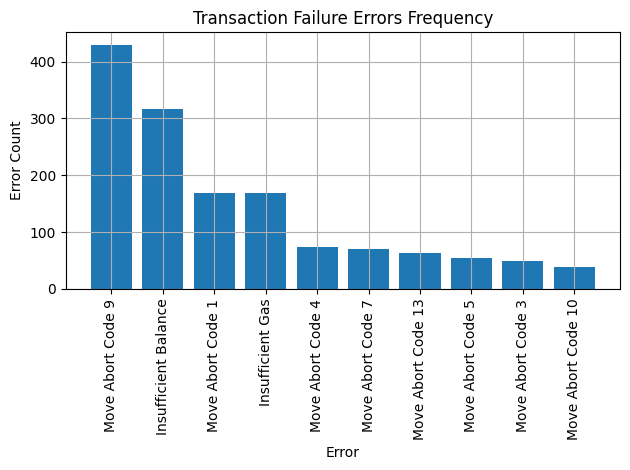

In [49]:
cur.execute("SELECT error FROM transactions WHERE status = 'failure';")

cur.execute("""
    SELECT error, COUNT(*) 
    FROM transactions
    WHERE status = 'failure'
      AND error IS NOT NULL
    GROUP BY error
    ORDER BY COUNT(*) DESC
    LIMIT 10;
""")

rows = cur.fetchall()

decoded_errors = []
counts = []

for error_bytes, count in rows:
    hex_str = error_bytes.hex()
    error_string = bytes.fromhex(hex_str)

    decoded_errors.append(error_string)
    counts.append(count)

df = pd.DataFrame({
    "error": decoded_errors,
    "count": counts
})

df["short_error"] = df["error"].apply(shorten_error)

plt.figure()
plt.bar(df["short_error"], df["count"])

plt.xlabel("Error")
plt.ylabel("Error Count")
plt.title("Transaction Failure Errors Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

Real conflicts

In [154]:
cur.execute("""SELECT
    oc1.transaction_digest AS tx1,
    oc2.transaction_digest AS tx2,
    oc1.address,
    oc1.input_version AS version,
    c.sequence_number AS checkpoint
FROM object_changes oc1
JOIN object_changes oc2
    ON oc1.address = oc2.address
    AND oc1.transaction_digest < oc2.transaction_digest
    AND oc1.input_version = oc2.input_version
JOIN transactions t1
    ON oc1.transaction_digest = t1.transaction_digest
JOIN transactions t2
    ON oc2.transaction_digest = t2.transaction_digest
JOIN checkpoints c
    ON t1.checkpoint_sequence = c.sequence_number
    AND t2.checkpoint_sequence = c.sequence_number
WHERE
    -- BOTH are write operations
    oc1.change_type IN ('mutated', 'created', 'deleted')
    AND oc2.change_type IN ('mutated', 'created', 'deleted');""")
rows = cur.fetchall()
len(rows)


0

Conflict graph with only successful transactions

In [ ]:
cur.execute("""SELECT
    oc1.transaction_digest AS tx1,
    oc2.transaction_digest AS tx2,
    oc1.address,
    oc1.input_version AS version,
    c.sequence_number AS checkpoint
FROM object_changes oc1
JOIN object_changes oc2
    ON oc1.address = oc2.address
    AND oc1.transaction_digest < oc2.transaction_digest
    AND oc1.input_version = oc2.input_version
JOIN transactions t1
    ON oc1.transaction_digest = t1.transaction_digest
JOIN transactions t2
    ON oc2.transaction_digest = t2.transaction_digest
JOIN checkpoints c
    ON t1.checkpoint_sequence = c.sequence_number
    AND t2.checkpoint_sequence = c.sequence_number
WHERE
    -- BOTH are write operations
    oc1.change_type IN ('mutated', 'created', 'deleted')
    AND oc2.change_type IN ('mutated', 'created', 'deleted');""")
rows = cur.fetchall()

Compute graph characteristics

In [ ]:
G = nx.Graph()
G.add_edges_from(conflict_edges)

nx.density(G)
nx.diameter(G)
nx.average_degree_connectivity(G)
nx.transitivity(G)
nx.algorithms.coloring.greedy_color(G)
nx.approximation.max_clique(G)
nx.connected_components(G)

Identify smart contract hotspots

In [ ]:
cur.execute("""SELECT address, COUNT(*)
FROM object_changes
WHERE change_type IN ('mutated')
GROUP BY address
ORDER BY COUNT(*) DESC
LIMIT 20;""")


Identify smart contract interaction graphs

In [ ]:
cur.execute("""SELECT kind, COUNT(*)
FROM transactions
GROUP BY kind;""")
